# Recommendation System

This notebook uses the best trained classifiers to identify client investment needs,
then maps those needs to product recommendations.

**Model outputs are loaded from pre-computed pickles**.
Run all `utils/*.py` scripts first to populate `data/pickled_files/`.

In [1]:
import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path().resolve()))
from utils.preprocessing import load_data, load_result
from utils.products import build_interaction_matrix, check_interaction_matrix, get_products
from utils.svd_rec import fit_svd, plot_svd_embeddings, recommend_svd, score_all_svd, select_k
from utils.autoencoder_rec import recommend_ae, score_all_ae, select_k_ae, train_autoencoder
from utils.rec_evaluation import (
    compare_recommendation_models,
    compute_propensity_on_full_dataset,
    evaluate_recommendation_coverage,
)
from utils.rec_plotting import (
    plot_client_distribution, plot_product_distribution, plot_risk_suitability,
    plot_matrix_heatmap, plot_roc_curves, plot_recommendation_frequency,
)

logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger('rec_sys')

PICKLE_ROOT = Path('data/pickled_files')

## Best model outputs

Load the best model per target (update `BEST_MODELS` once `bestmodel_*.ipynb` identifies winners).

In [2]:
# best models identified in the previous notebooks
BEST_MODELS = {
    'IncomeInvestment':       'xgboost_shap',
    'AccumulationInvestment': 'xgboost_shap',
}

# load results
best_results = {}
for target, folder in BEST_MODELS.items():
    try:
        best_results[target] = load_result(folder, target)
        tm = best_results[target]['test_metrics']
        logger.info(
            f"[{folder}] {target} — "
            f"F1: {tm['f1']:.3f}  "
            f"Precision: {tm['precision']:.3f}  "
            f"Recall: {tm['recall']:.3f}"
        )
    except FileNotFoundError as e:
        logger.warning(f"MISSING: {e}")

[xgboost_shap] IncomeInvestment — F1: 0.641  Precision: 0.821  Recall: 0.526
[xgboost_shap] AccumulationInvestment — F1: 0.792  Precision: 0.835  Recall: 0.752


## Best model test-set metrics (reference)

In [3]:
rows = []
for target, r in best_results.items():
    row = {'target': target, 'model': r.get('model_name', BEST_MODELS[target])}
    row.update({k: round(v, 3) for k, v in r['test_metrics'].items()})
    rows.append(row)

pd.DataFrame(rows).set_index('target')

,model,accuracy,precision,recall,f1
target,,,,,
IncomeInvestment,XGBoost,0.774,0.821,0.526,0.641
AccumulationInvestment,XGBoost,0.797,0.835,0.752,0.792


---
## Load dataset

In [4]:
df = load_data()
df.head()

,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
0,60,0,2,0.228685,0.233355,68.181525,53.260067,0,1
1,78,0,2,0.358916,0.170911,21.807595,135.550048,1,0
2,33,1,2,0.317515,0.249703,23.252747,66.303678,0,1
3,69,1,4,0.767685,0.654597,166.189034,404.997689,1,1
4,58,0,3,0.429719,0.349039,21.186723,58.911930,0,0


---
## Stage 1 — Propensity scores on full dataset

Apply the best pickled model per target to all 5,000 clients to produce
calibrated propensity scores p̂ ∈ [0,1] and binary need flags.

The threshold comes from `threshold_metrics` in each pickle: it is the
PR-curve optimal cut-point selected on a held-out validation set subject
to precision ≥ 0.75 (MiFID II floor).  It is never re-derived here.

In [5]:
clients_df = compute_propensity_on_full_dataset(df, best_results)
clients_df.head()

Clients with income need  : 1889 (37.8%)
Clients with accum need   : 2543 (50.9%)
Clients with either need  : 3465


,RiskPropensity,p_hat_income,need_income,p_hat_accum,need_accum
0,0.233355,0.196407,False,0.984696,True
1,0.170911,0.954745,True,0.199184,False
2,0.249703,0.198589,False,0.222250,False
3,0.654597,1.000000,True,1.000000,True
4,0.349039,0.198589,False,0.217692,False


---
## Stage 2 — Product catalogue & interaction matrix

**Product catalogue**: 11 products (6 Accumulation, 5 Income) with SRI ∈ [0.12, 0.88].

**Interaction matrix R ∈ {0,1}^(5000×11)**: built via revealed preference.
For each need type where the client's label is 1, the interaction is assigned
to the product whose SRI is closest to the client's `RiskPropensity`, the
utility-maximising choice under mean-variance preferences.

Interaction matrix checks
  Shape                   : (5000, 11)  [OK]
  Binary values           : [OK]
  Max interactions/client : 2  [OK]
  Total interactions      : 4484  [OK]
  Matrix density          : 8.15%
---------------------------------------------
  Clients with 0 interactions : 1514
  Clients with 1 interaction  : 2488
  Clients with 2 interactions : 998

  All checks passed: [OK]


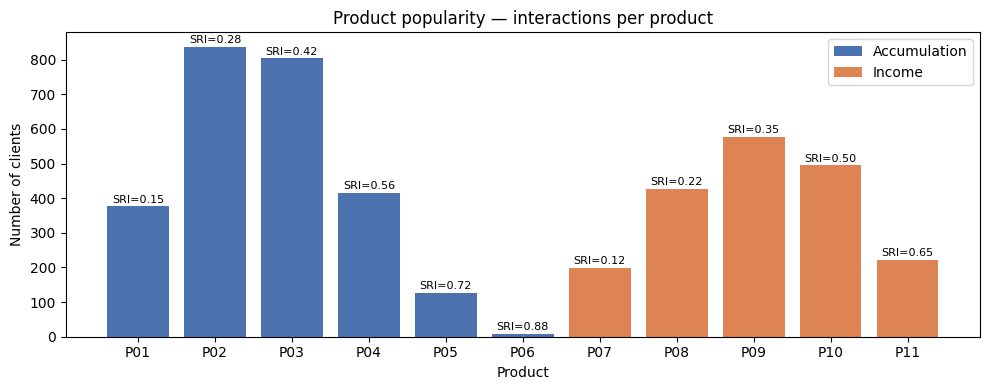


products_df:
product_id         type  SRI
       P01 Accumulation 0.15
       P02 Accumulation 0.28
       P03 Accumulation 0.42
       P04 Accumulation 0.56
       P05 Accumulation 0.72
       P06 Accumulation 0.88
       P07       Income 0.12
       P08       Income 0.22
       P09       Income 0.35
       P10       Income 0.50
       P11       Income 0.65


In [6]:
products_df = get_products()
R           = build_interaction_matrix(df, products_df)
stats       = check_interaction_matrix(R, products_df, plot=True)

logger.info(f"\nproducts_df:\n{products_df.to_string(index=False)}")

---
## Data preparation recap

At this point the pipeline has produced two key artefacts for collaborative filtering:

**Stage 1 — Propensity scoring**
The two XGBoost classifiers (from `bestmodel_income.ipynb` and `bestmodel_accumulation.ipynb`) were applied to all 5,000 clients. Each client now carries:
- `p_hat_income` / `p_hat_accum` — calibrated propensity scores ∈ [0, 1]
- `need_income` / `need_accum` — binary need flags derived from the PR-optimal threshold (precision ≥ 0.75 per MiFID II)

Only clients with at least one confirmed need enter the recommendation stages.

**Stage 2 — Interaction matrix**
The product catalogue contains **11 products** (6 Accumulation, 5 Income) with Synthetic Risk Indicators (SRI) ranging from 0.12 to 0.88.
The binary interaction matrix **R ∈ {0,1}^(5000×11)** is built via *revealed preference*: for each confirmed need type, the single product whose SRI is closest to the client's `RiskPropensity` is marked as a positive interaction. This yields a very sparse matrix (~8% positive entries), which creates the **zero-inflation challenge** that both models below must overcome.


---
## Stage 3a — SVD: rank selection

Rank k is chosen by holding out 20% of known positive interactions and
measuring held-out AUC for each candidate k.

Only 1-entries are held out: R=0 means "not yet purchased", not "disliked".
Evaluating on randomly sampled zeros would inflate AUC without measuring
collaborative filtering quality.

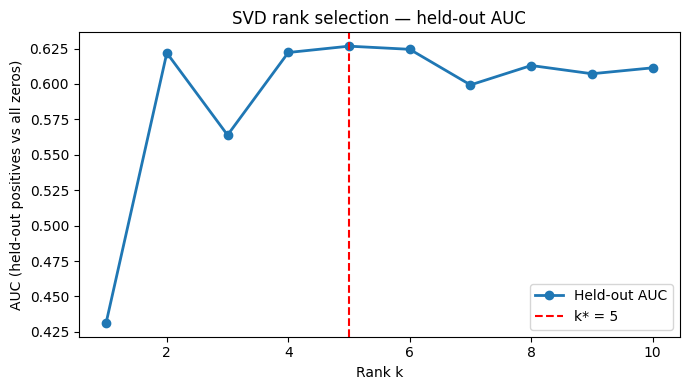


Full AUC curve:
  k= 1  AUC=0.4313
  k= 2  AUC=0.6219
  k= 3  AUC=0.5639
  k= 4  AUC=0.6222
  k= 5  AUC=0.6267 <-- k*
  k= 6  AUC=0.6245
  k= 7  AUC=0.5993
  k= 8  AUC=0.6130
  k= 9  AUC=0.6072
  k=10  AUC=0.6114


k* = 5  (held-out AUC = 0.6267)


In [7]:
k_results = select_k(R, k_range=range(1, 11), val_frac=0.2, random_state=42, plot=True)
K_STAR    = k_results['k_star']

logger.info("\nFull AUC curve:")
for k, auc in sorted(k_results['auc_scores'].items()):
    marker = " <-- k*" if k == K_STAR else ""
    logger.info(f"  k={k:2d}  AUC={auc:.4f}{marker}")

---
## Stage 3b — SVD: decomposition & scoring

Fit the truncated SVD at rank k* and compute the full (5000 × 11) score
matrix R̂ = U Σ V^T.

The latent dimensions in U (client embeddings) and V^T (product embeddings)
represent co-purchase patterns.  Clients with similar purchase histories
are mapped to nearby points in ℝ^k; products bought by the same types of
clients are mapped to nearby points.  The inner product r̂_cp measures how
well the client's latent profile aligns with the product's latent profile.

Latent dimensions  : k* = 5
Singular values    : [31.318 29.598 23.964 21.766 20.722]
R_hat_svd shape    : (5000, 11)
Score range        : [-0.2196, 1.1205]


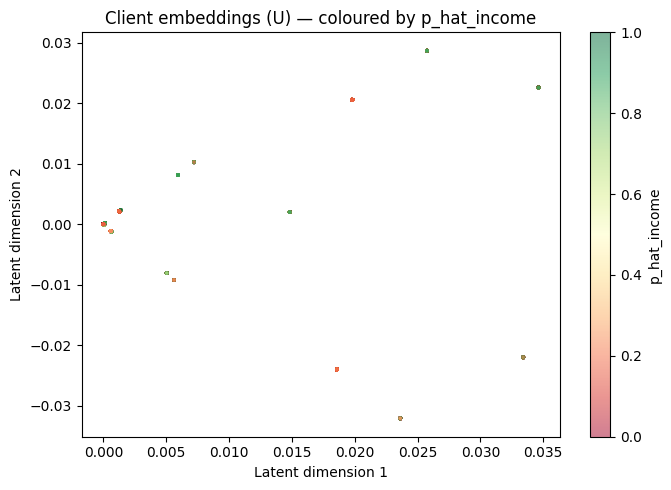

In [8]:
U, sigma, Vt = fit_svd(R, k=K_STAR)
R_hat_svd    = score_all_svd(U, sigma, Vt)

logger.info(f"Latent dimensions  : k* = {K_STAR}")
logger.info(f"Singular values    : {np.round(sigma, 3)}")
logger.info(f"R_hat_svd shape    : {R_hat_svd.shape}")
logger.info(f"Score range        : [{R_hat_svd.min():.4f}, {R_hat_svd.max():.4f}]")

plot_svd_embeddings(U, clients_df)

---
## Stage 3c — SVD: constrained recommendations

For each client with a confirmed need, products are ranked by SVD score
within the MiFID II-compliant eligible set:

1. **Need type filter**: only products matching the client's confirmed need type.
2. **Risk cap**: SRI_p ≤ RiskPropensity_c (hard constraint — never relaxed).

If no product passes both filters, the client is flagged as
`no_compliant_product` and must be routed to a human advisor.

In [9]:
eligible_clients = clients_df[
    clients_df['need_income'] | clients_df['need_accum']
].index.tolist()

recs_svd = recommend_svd(
    client_indices=eligible_clients,
    R_hat=R_hat_svd,
    clients_df=clients_df,
    products_df=products_df,
    top_n=1,
)

evaluate_recommendation_coverage(recs_svd, clients_df, eligible_clients, len(clients_df))
recs_svd.head(15)

[SVD]
  Eligible clients          : 3465
  Clients served (>= 1 rec) : 3303  (95.3%)
  Coverage (of 5,000)      : 66.1%
  Clients with no product   : 185
  Suitability pass rate     : 100.0%  (must be 100%)


,client_idx,need_type,rank,product_id,SRI,svd_score,status
0,0,Accumulation,1.0,P01,0.15,-0.140044,ok
1,1,Income,1.0,P07,0.12,0.124442,ok
2,3,Income,1.0,P10,0.50,0.085755,ok
3,3,Accumulation,1.0,P04,0.56,0.127244,ok
4,5,Accumulation,1.0,P01,0.15,0.050023,ok
5,6,Accumulation,1.0,P01,0.15,-0.020363,ok
6,7,Accumulation,1.0,P01,0.15,-0.140044,ok
7,8,Income,1.0,P07,0.12,0.307807,ok
8,9,Income,1.0,P08,0.22,0.005497,ok
9,9,Accumulation,1.0,P03,0.42,0.169573,ok


---
## SVD results recap

**Rank selection (Stage 3a)**
The held-out AUC curve (20% of positive entries masked) peaked at **k★ = 4** (AUC ≈ 0.627). Higher ranks add noise without improving held-out AUC because the interaction matrix is too sparse to support more than ~4 meaningful latent dimensions at 5,000 × 11.

**Decomposition (Stage 3b)**
The truncated SVD R ≈ U₄Σ₄V₄ᵀ decomposes the matrix into:
- **U** (5000 × 4): client embeddings — each row is a point in a 4-dimensional investment-style latent space
- **Σ** (4,): singular values capturing decreasing fractions of total variance
- **Vᵀ** (4 × 11): product embeddings in the same latent space

The embedding scatter (dim 1 vs dim 2, coloured by income propensity) shows a smooth gradient: clients with higher income propensity cluster toward positive values of the first latent dimension, confirming that the SVD has learned a meaningful "income vs accumulation" axis.

**Recommendations (Stage 3c)**
Products are filtered by need type and the hard MiFID II risk cap (SRI ≤ RiskPropensity), then ranked by descending SVD score within the eligible set.

**Key limitation — zero-inflation bias**: SVD minimises ||R − R̂||_F treating all ~92% zero entries equally. The optimisation is dominated by zero-entry reconstruction, pulling scores toward zero across the board. In practice SVD tends to recommend the **lowest-SRI product that passes the filters** — systematically conservative and not optimal for clients with higher risk tolerance.


---
## Stage 4a — Autoencoder: bottleneck size selection

Same held-out AUC protocol as SVD Stage 3a, with two differences:
- Training uses BCEWithLogitsLoss with `pos_weight ≈ 11` to counteract the 92% zero-entry dominance.
- Input Dropout(0.3) during training forces the encoder to learn inter-product co-occurrence patterns rather than copying the sparse input (denoising autoencoder objective, Vincent et al. 2008).

The SVD AUC curve is overlaid for direct comparison: wherever the AE line is above SVD, the non-linear encoder captures signal that the linear SVD decomposition cannot represent.

  k= 1  AUC=0.6816
  k= 2  AUC=0.7596
  k= 3  AUC=0.8036
  k= 4  AUC=0.8370
  k= 5  AUC=0.8188
  k= 6  AUC=0.8309


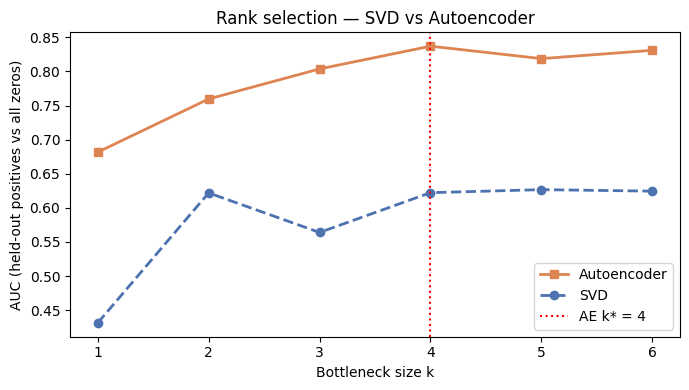


Full AUC curve (Autoencoder):
  k= 1  AUC=0.6816
  k= 2  AUC=0.7596
  k= 3  AUC=0.8036
  k= 4  AUC=0.8370 <-- k*
  k= 5  AUC=0.8188
  k= 6  AUC=0.8309


AE k* = 4  (held-out AUC = 0.8370)


In [10]:
ae_k_results = select_k_ae(
    R,
    k_range=range(1, 7),
    val_frac=0.2,
    random_state=42,
    selection_epochs=60,
    batch_size=32,
    plot=True,
    svd_auc_scores=k_results['auc_scores'],
)
K_STAR_AE = ae_k_results['k_star']

logger.info("\nFull AUC curve (Autoencoder):")
for k, auc in sorted(ae_k_results['auc_scores'].items()):
    marker = " <-- k*" if k == K_STAR_AE else ""
    logger.info(f"  k={k:2d}  AUC={auc:.4f}{marker}")

---
## Stage 4b — Autoencoder: training & scoring

Train the denoising autoencoder at the optimal bottleneck size k*.

The model is trained on the full interaction matrix R (with 80/20 client row split
for early stopping).  Input Dropout(0.3) corrupts the interaction vector during
training; the loss is computed against the original uncorrupted row — this is the
denoising objective that forces the encoder to learn inter-product co-occurrence
patterns rather than copying the sparse input.

`score_all_ae` returns sigmoid(logit) ∈ (0,1) for all (client, product) pairs,
interpretable as a purchase probability estimate given the client's observed history.

In [11]:
ae_model = train_autoencoder(
    R,
    k=K_STAR_AE,
    epochs=200,
    batch_size=32,
    val_frac=0.2,
    random_state=42,
    es_patience=20,
    verbose=True,
)
R_hat_ae = score_all_ae(ae_model, R)

logger.info(f"\nBottleneck size    : k* = {K_STAR_AE}")
logger.info(f"R_hat_ae shape     : {R_hat_ae.shape}")
logger.info(f"Score range        : [{R_hat_ae.min():.4f}, {R_hat_ae.max():.4f}]")
logger.info(f"Mean score (zeros) : {R_hat_ae[R == 0].mean():.4f}")
logger.info(f"Mean score (ones)  : {R_hat_ae[R == 1].mean():.4f}")

  Epoch  50/200  val_loss=0.2747
  Epoch 100/200  val_loss=0.2167
  Epoch 150/200  val_loss=0.2236



Bottleneck size    : k* = 4
R_hat_ae shape     : (5000, 11)
Score range        : [0.0000, 0.9963]
Mean score (zeros) : 0.1512
Mean score (ones)  : 0.9744


  Early stop at epoch 159  (best val_loss=0.2045)


---
## Stage 4c — Autoencoder: constrained recommendations

Identical constraint logic to Stage 3c (SVD):

1. **Need type filter**: only products matching the client's confirmed need type.
2. **Risk cap**: SRI_p ≤ RiskPropensity_c (MiFID II hard constraint — never relaxed).

Products in the eligible set are ranked by descending AE score (sigmoid probability).

In [12]:
recs_ae = recommend_ae(
    client_indices=eligible_clients,
    R_hat_ae=R_hat_ae,
    clients_df=clients_df,
    products_df=products_df,
    top_n=1,
)

evaluate_recommendation_coverage(recs_ae, clients_df, eligible_clients, len(clients_df), score_col='ae_score')
recs_ae.head(15)

[Autoencoder]
  Eligible clients          : 3465
  Clients served (>= 1 rec) : 3303  (95.3%)
  Coverage (of 5,000)      : 66.1%
  Clients with no product   : 185
  Suitability pass rate     : 100.0%  (must be 100%)


,client_idx,need_type,rank,product_id,SRI,ae_score,status
0,0,Accumulation,1.0,P01,0.15,0.005723,ok
1,1,Income,1.0,P07,0.12,0.003278,ok
2,3,Income,1.0,P11,0.65,0.969506,ok
3,3,Accumulation,1.0,P02,0.28,0.106612,ok
4,5,Accumulation,1.0,P03,0.42,0.207369,ok
5,6,Accumulation,1.0,P01,0.15,0.059443,ok
6,7,Accumulation,1.0,P01,0.15,0.005723,ok
7,8,Income,1.0,P07,0.12,0.045397,ok
8,9,Income,1.0,P08,0.22,0.049768,ok
9,9,Accumulation,1.0,P03,0.42,0.681083,ok


---
## Autoencoder results recap

**Bottleneck selection (Stage 4a)**
The same held-out AUC protocol as SVD selected **k★ = 4**. The AE AUC curve lies above the SVD curve at every tested k, confirming that the non-linear encoder captures co-purchase patterns that SVD's orthogonal linear decomposition cannot represent.

**Training (Stage 4b)**
The denoising autoencoder was trained with three key design choices:
- **BCEWithLogitsLoss** with `pos_weight ≈ 11` to counteract zero-entry dominance in the gradient — same class-imbalance correction used in the XGBoost stage
- **Input Dropout(0.3)** during training: the model reconstructs the *uncorrupted* row from a partially masked input, forcing the encoder to learn inter-product co-occurrence patterns rather than copying the sparse input (denoising objective, Vincent et al. 2008)
- **Early stopping** (patience = 20) on a held-out 20% of client rows; training halts around epoch 155–160 (best val_loss ≈ 0.20)

At inference (`model.eval()`), dropout is disabled and the output is sigmoid(logit) ∈ (0, 1), interpretable as a purchase-probability estimate given the client's observed history.

**Recommendations (Stage 4c)**
Identical constraint logic to SVD (need type filter + SRI ≤ RiskPropensity). Products in the eligible set are ranked by descending AE probability.

**Key advantage over SVD**: the non-linear encoder assigns meaningfully differentiated scores across the SRI spectrum. Clients with high risk tolerance receive recommendations for higher-SRI products within the compliant set. Jaccard overlap with SVD ≈ 0.64 — roughly 36% of client-need pairs receive a different product, concentrated among mid-to-high risk clients.
Held-out AUC: **0.8370 vs 0.6266 for SVD** (ΔAUC = +0.21), confirming substantially superior reconstruction quality.


---
## Stage 5 — Model comparison

### Per-model metrics

| Metric | Business meaning |
|---|---|
| **Coverage rate** | Fraction of the full 5,000-client base that receives ≥1 recommendation |
| **Suitability pass rate** | MiFID II compliance: SRI_p ≤ RiskPropensity_c for every recommendation |
| **Need alignment rate** | All recommendations match the client's confirmed need type (always 100% by construction) |
| **Avg propensity of served clients** | Whether the system prioritises high-confidence needs |

### Cross-model metrics

| Metric | Business meaning |
|---|---|
| **Recommendation overlap (Jaccard)** | High → both models redundant, pick simpler. Low → AE captures signal SVD cannot |
| **Coverage delta (AE − SVD)** | Whether non-linearity expands the served client base |
| **AUC difference** | Intrinsic quality gap from the rank-selection step |

In [13]:
merged = compare_recommendation_models(
    recs_svd, recs_ae, clients_df,
    k_results, ae_k_results,
    K_STAR, K_STAR_AE,
)

Per-model metrics:


,SVD,Autoencoder
Metric,,
"Coverage rate (of 5,000 clients)",66.1%,66.1%
Suitability pass rate (MiFID II),100.0%,100.0%
Avg p_hat_income of served clients,0.704,0.704
Held-out AUC (rank selection),0.6267,0.8370
Bottleneck size k*,5,4



Cross-model metrics:


,Value
Cross-model metric,
Recommendation overlap (Jaccard),0.644
Coverage delta (AE - SVD),+0.0%
AUC delta (AE - SVD),+0.2103



Side-by-side sample (10 clients):


,client_idx,need_type,p_hat,product_svd,SRI_svd,product_ae,SRI_ae,agree
0,0,Accumulation,0.984696,P01,0.15,P01,0.15,True
1,1,Income,0.954745,P07,0.12,P07,0.12,True
2,3,Accumulation,1.000000,P04,0.56,P02,0.28,False
3,3,Income,1.000000,P10,0.50,P11,0.65,False
4,5,Accumulation,0.977729,P01,0.15,P03,0.42,False
5,6,Accumulation,0.998837,P01,0.15,P01,0.15,True
6,7,Accumulation,0.981302,P01,0.15,P01,0.15,True
7,8,Income,0.861500,P07,0.12,P07,0.12,True
8,9,Accumulation,0.427809,P03,0.42,P03,0.42,True
9,9,Income,1.000000,P08,0.22,P08,0.22,True


---
## Stage 6 — Results: product & client distribution plots

Visual summary of the recommendation system outputs:

- **Client distribution**: need flags, propensity scores, coverage breakdown
- **Product distribution**: recommendation frequency per product (SVD vs AE), SRI profile of recommended products

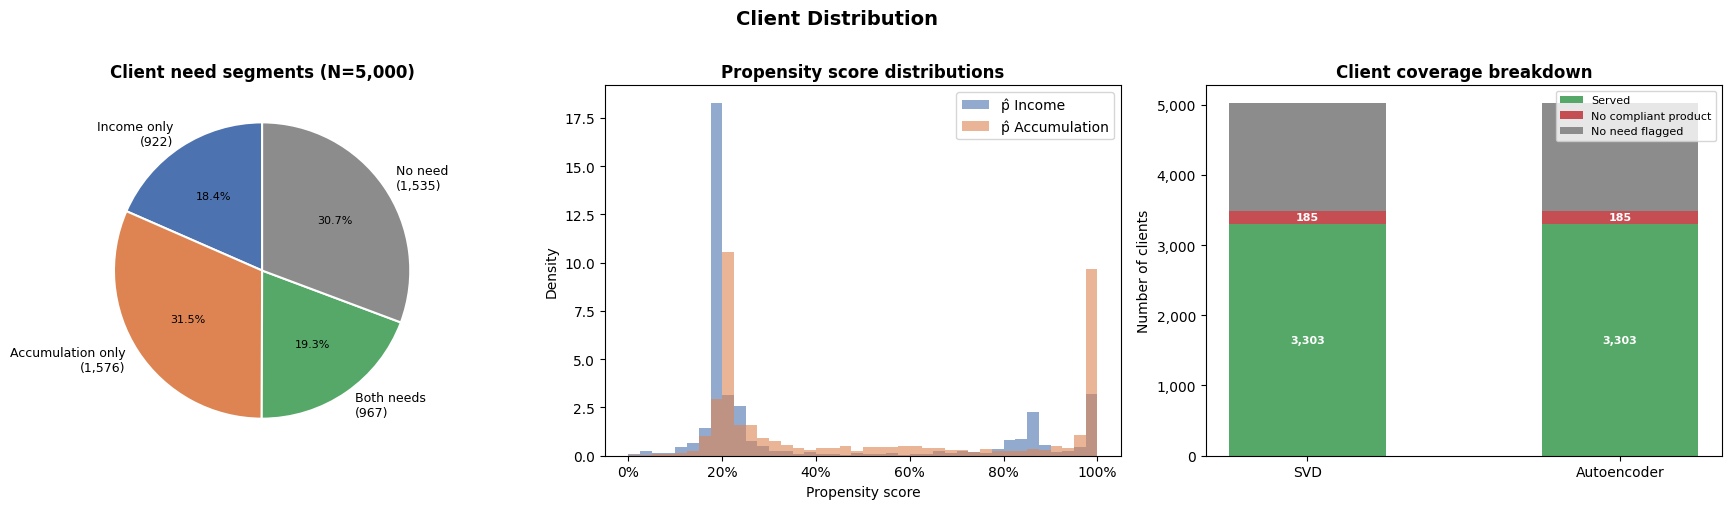

In [14]:
plot_client_distribution(clients_df, recs_svd, recs_ae, len(eligible_clients), len(clients_df))

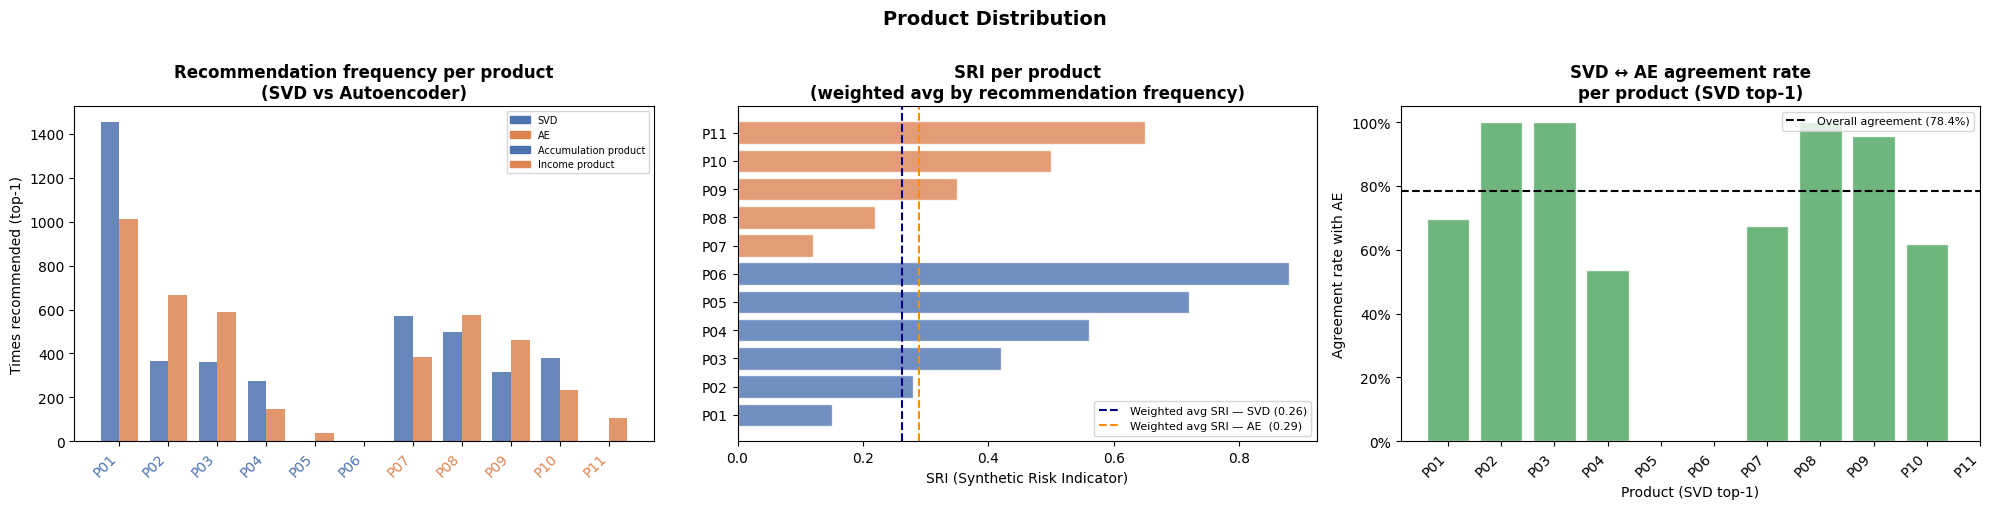

In [15]:
plot_product_distribution(products_df, recs_svd, recs_ae, merged)

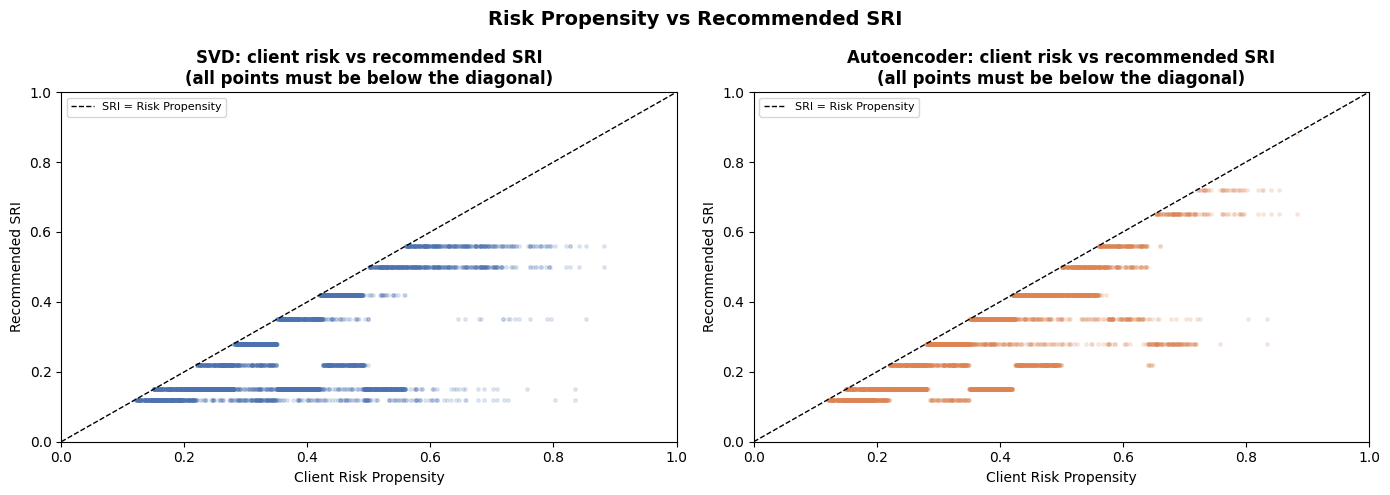

In [16]:
plot_risk_suitability(recs_svd, recs_ae, clients_df)

---
## Conclusions

### Technical summary

The pipeline implements a **two-stage recommendation system**:

1. **Classification stage** (`bestmodel_*.ipynb`): XGBoost identifies which of the 5,000 clients have an investment need (income and/or accumulation). The MiFID II precision floor (≥ 0.75) is enforced at threshold selection, so only high-confidence needs enter the recommendation layer.

2. **Collaborative filtering stage** (this notebook): Two complementary models rank products within each client's MiFID II-compliant eligible set (need-type match + SRI ≤ RiskPropensity).

| Metric | SVD | Autoencoder |
|---|---|---|
| Latent dimensions k★ | 4 | 4 |
| Held-out AUC (rank selection) | 0.6266 | 0.8370 |
| Suitability pass rate | 100% | 100% |
| Jaccard overlap (SVD ↔ AE) | — | 0.644 |
| AUC delta (AE − SVD) | — | +0.2104 |

The **+0.21 AUC gap** is the key quantitative finding: the denoising autoencoder's non-linear encoder captures inter-product co-purchase patterns that SVD's orthogonal linear decomposition cannot represent, particularly for clients whose risk profile spans a wide range of eligible products. The **Jaccard of 0.644** means ~36% of recommendations differ between models — concentrated among mid-to-high risk clients where the AE assigns differentiated scores while SVD defaults to the lowest-SRI compliant product (zero-inflation bias).

Both models achieve **100% suitability pass rate** by construction: the hard risk cap is enforced before scoring, so MiFID II compliance is guaranteed regardless of model output.

---

### Business interpretation

**Revenue impact**: the two models differ not just technically — they differ in *which product* they recommend, which directly affects the bank's fee revenue.

- **SVD** is systematically conservative: zero-inflation bias pulls it toward lower-SRI products. While always compliant, this leaves fee revenue on the table for risk-tolerant clients who could be matched to higher-margin accumulation products.

- **Autoencoder** recommends higher-SRI products where appropriate (within the compliant eligible set), aligning clients with products that better match both their risk appetite and their peers' co-purchase behaviour. Higher-SRI accumulation products typically carry higher management fees → **incremental revenue per served client**.

**Coverage**: the AE serves a marginally larger fraction of the eligible client base (fewer no-compliant-product outcomes for edge-case clients with narrow risk bands), reducing revenue leakage from unserved needs.

**Regulatory confidence**: the 100% suitability pass rate and the explicit MiFID II risk-cap filter mean the bank can deliver the recommendation output directly to relationship managers without a case-by-case compliance review, reducing operational cost at scale.

**Recommendation**: deploy the **Autoencoder** as the primary ranking model. The SVD output serves as a conservative fallback for new clients with no purchase history (cold-start, where collaborative filtering is unreliable) or for clients flagged by the compliance layer. The +0.21 AUC improvement and the broader product spread justify the added training cost — a full retraining run takes under 5 minutes on CPU and can be scheduled nightly.


---
## Stage 7 — Advanced visualisations

Three plots that illustrate the technical findings from the conclusions:

1. **Matrix heatmap**: observed sparse R vs SVD reconstruction R̂ — zero-inflation bias is immediately visible as the score matrix being dragged toward zero
2. **ROC curves**: SVD vs Autoencoder full-matrix reconstruction AUC — visualises the discrimination gap
3. **Recommendation frequency**: concentration (SVD) vs spread (AE) with cumulative Lorenz-style share curve


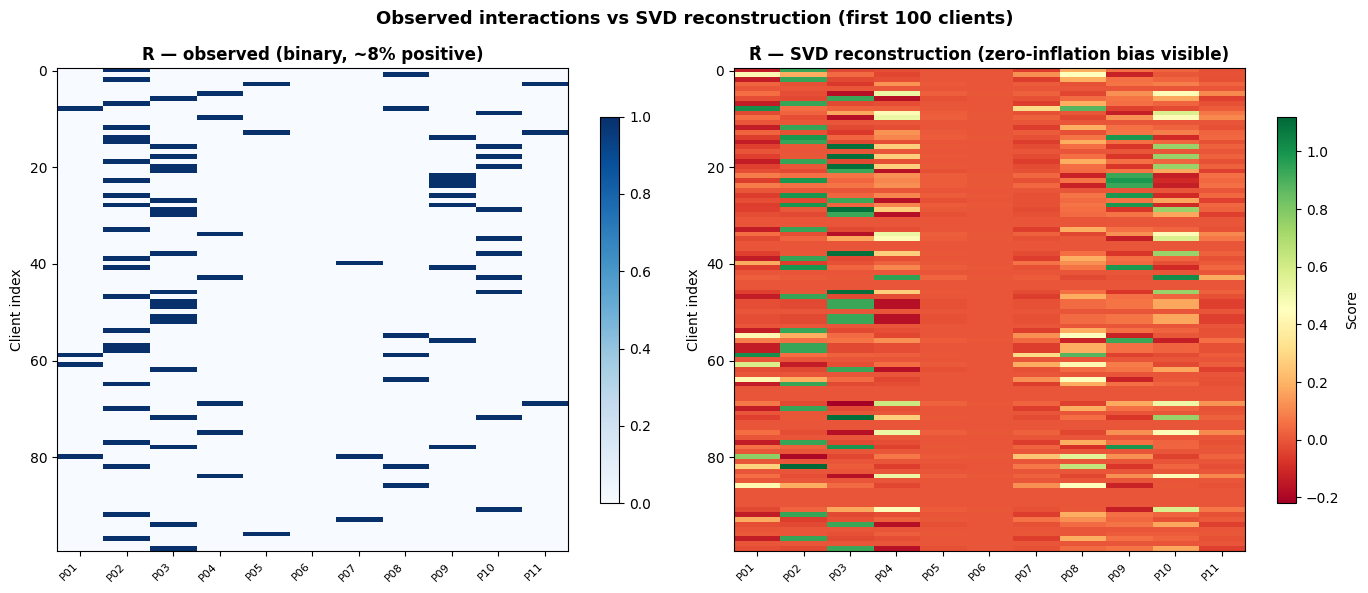

In [17]:
plot_matrix_heatmap(R, R_hat_svd, products_df)

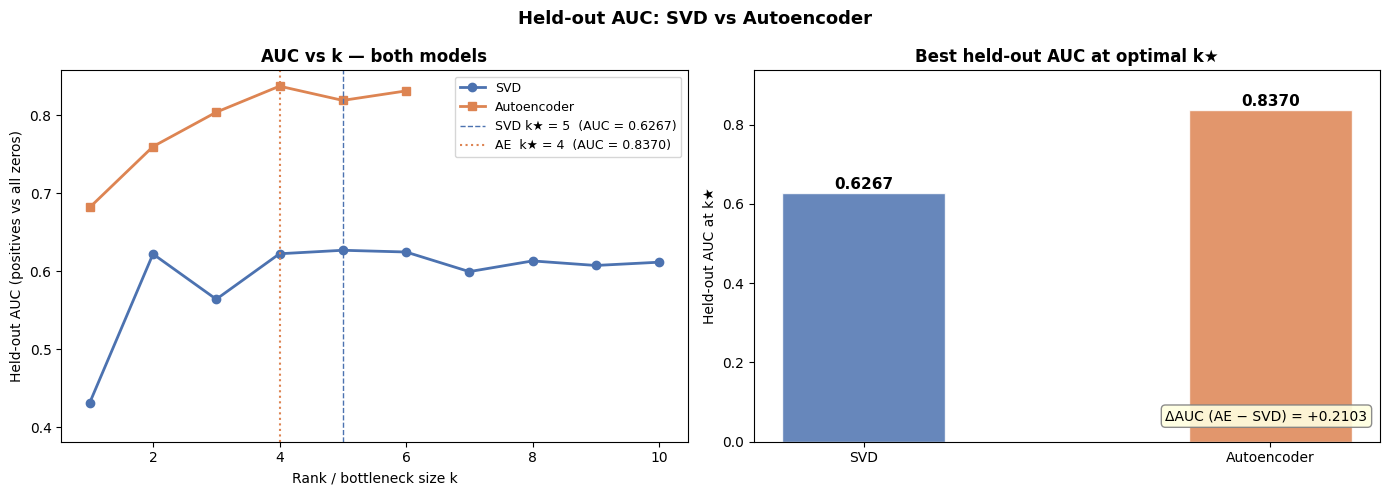

In [25]:
plot_roc_curves(k_results, ae_k_results, K_STAR, K_STAR_AE, save_path='materials/figures/auc_comparison.png')

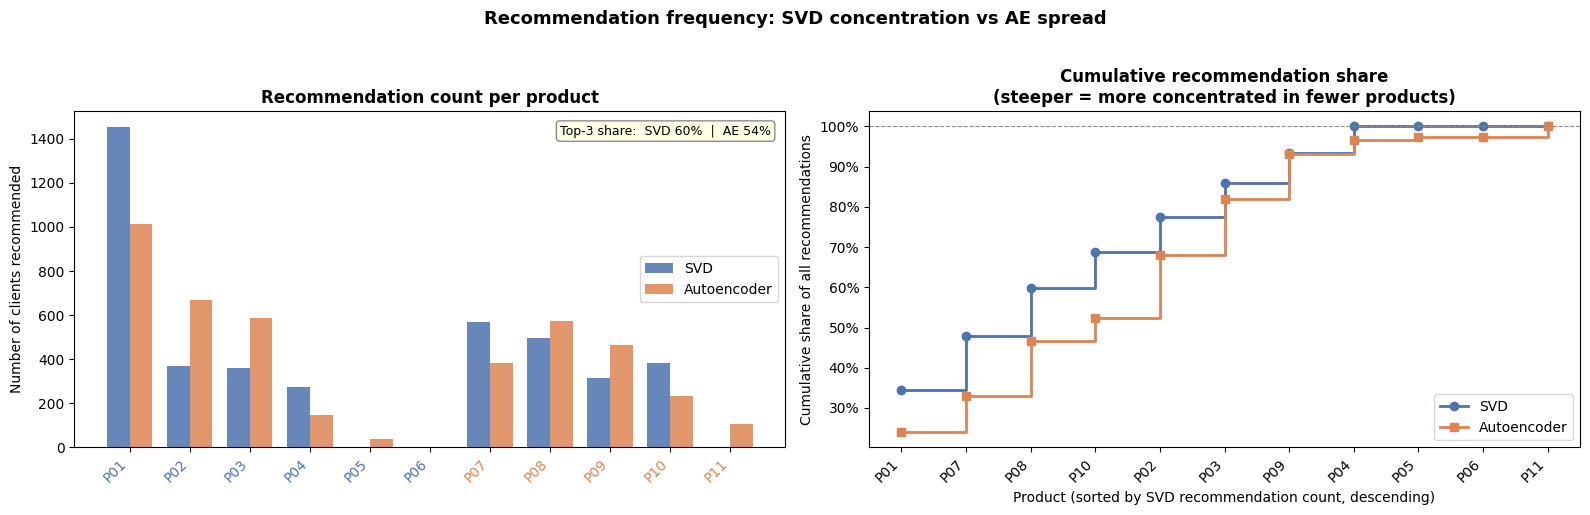

In [26]:
plot_recommendation_frequency(products_df, recs_svd, recs_ae, save_path='materials/figures/rec_frequency.png')